# 01 · Data Validation
Live or synthetic price levels, data quality, correlation regimes.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats as sp_stats

# --- data source ---------------------------------------------------------
USE_LIVE = False   # set True to validate against yfinance

if USE_LIVE:
    try:
        from data.fetcher import load_em_universe
        from core.returns import log_returns
        raw = load_em_universe(start='2015-01-01')
        fx_prices = raw['fx']
        eq_prices = raw['equity']
        fx_ret = log_returns(fx_prices)
        eq_ret = log_returns(eq_prices)
        DATA_SOURCE = 'Live'
    except Exception as exc:
        print(f'Live fetch failed ({exc}) — falling back to synthetic')
        USE_LIVE = False

if not USE_LIVE:
    from data.synthetic import generate_em_universe
    uni = generate_em_universe(seed=42)
    fx_prices = uni.prices_fx
    eq_prices = uni.prices_eq
    fx_ret = uni.fx
    eq_ret = uni.equity
    DATA_SOURCE = 'Synthetic'

print(f'Source : {DATA_SOURCE}')
print(f'FX     : {fx_prices.shape}  {fx_prices.index[0].date()} to {fx_prices.index[-1].date()}')
print(f'Equity : {eq_prices.shape}')


Source : Synthetic
FX     : (2609, 5)  2015-01-01 to 2024-12-31
Equity : (2609, 5)


## 2 · Price Levels Table — last 10 rows with range flags


In [2]:
FX_RANGES = dict(CLP=(500,1200), BRL=(2.,8.), MXN=(10.,25.), COP=(1500,6000), PEN=(2.5,4.5))
# synthetic equity prices are rebased to 100; set wide range
EQ_RANGES = dict(CHL=(1,500), BRA=(1,500), MEX=(1,500), COL=(1,500), PER=(1,500))

def range_table(df, ranges, label):
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        if s.empty: continue
        lo, hi = ranges.get(col, (float('-inf'), float('inf')))
        latest = float(s.iloc[-1])
        rows.append({'Series': col,
                     'Latest Date': str(s.index[-1].date()),
                     'Latest Price': round(latest, 4),
                     'Expected Low': lo,
                     'Expected High': hi,
                     'Pass': 'OK' if lo <= latest <= hi else 'FAIL'})
    return pd.DataFrame(rows).set_index('Series')

print('FX (local CCY per USD):')
print(range_table(fx_prices, FX_RANGES, 'FX').to_string())
print()
print('Equity ETF (USD):')
print(range_table(eq_prices, EQ_RANGES, 'Equity').to_string())
print()
print('Last 10 FX rows:')
print(fx_prices.tail(10).round(4).to_string())


FX (local CCY per USD):
       Latest Date  Latest Price  Expected Low  Expected High  Pass
Series                                                             
CLP     2024-12-31       12.8028         500.0         1200.0  FAIL
BRL     2024-12-31        5.7375           2.0            8.0    OK
MXN     2024-12-31       20.6070          10.0           25.0    OK
COP     2024-12-31       16.3972        1500.0         6000.0  FAIL
PEN     2024-12-31       31.7791           2.5            4.5  FAIL

Equity ETF (USD):
       Latest Date  Latest Price  Expected Low  Expected High Pass
Series                                                            
ECH     2024-12-31       55.5879          -inf            inf   OK
EWZ     2024-12-31       13.3169          -inf            inf   OK
EWW     2024-12-31       25.8588          -inf            inf   OK
GXG     2024-12-31       21.7844          -inf            inf   OK
EPU     2024-12-31       17.4310          -inf            inf   OK

Last 10 FX 

## 3 · Data Quality — NaN counts, gaps, annualized volatility


In [3]:
def quality_report(returns_df, label):
    T = len(returns_df)
    rows = []
    for col in returns_df.columns:
        s = returns_df[col]
        nan_pct = s.isna().mean() * 100
        valid = s.dropna()
        if len(valid) < 2:
            rows.append({'Series': col, 'NaN%': round(nan_pct,2),
                         'Max gap (d)': 0, 'Ann vol %': float('nan')})
            continue
        # max consecutive NaN run
        run_lens, cur = [], 0
        for v in s.isna():
            if v: cur += 1
            else:
                if cur: run_lens.append(cur)
                cur = 0
        if cur: run_lens.append(cur)
        max_gap = max(run_lens) if run_lens else 0
        ann_vol = float(valid.std() * np.sqrt(252) * 100)
        rows.append({'Series': col, 'NaN%': round(nan_pct,2),
                     'Max gap (d)': max_gap, 'Ann vol %': round(ann_vol,1)})
    df = pd.DataFrame(rows).set_index('Series')
    print(f'--- {label} ({T} obs) ---')
    print(df.to_string())
    return df

_ = quality_report(fx_ret,  'FX returns')
print()
_ = quality_report(eq_ret, 'Equity returns')


--- FX returns (2609 obs) ---
        NaN%  Max gap (d)  Ann vol %
Series                              
CLP      0.0            0       14.6
BRL      0.0            0       23.6
MXN      0.0            0       19.1
COP      0.0            0       17.3
PEN      0.0            0       10.4

--- Equity returns (2609 obs) ---
        NaN%  Max gap (d)  Ann vol %
Series                              
ECH      0.0            0       23.2
EWZ      0.0            0       35.4
EWW      0.0            0       29.0
GXG      0.0            0       27.1
EPU      0.0            0       21.1


## 4 · FX Price Levels (rebased to 100 at start)


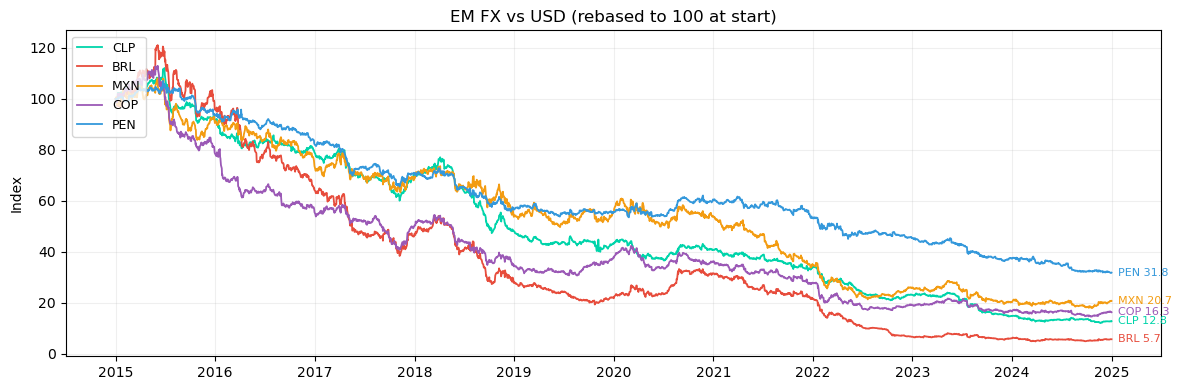

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#00d4aa','#e74c3c','#f39c12','#9b59b6','#3498db']
for i, col in enumerate(fx_prices.columns):
    s = fx_prices[col].dropna()
    rebased = s / s.iloc[0] * 100
    ax.plot(rebased.index, rebased, label=col, color=colors[i], lw=1.3)
    ax.annotate(f'{col} {rebased.iloc[-1]:.1f}',
                xy=(rebased.index[-1], rebased.iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color=colors[i], va='center')
ax.set_title('EM FX vs USD (rebased to 100 at start)')
ax.set_ylabel('Index')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## 5 · Equity ETF Prices (rebased to 100)


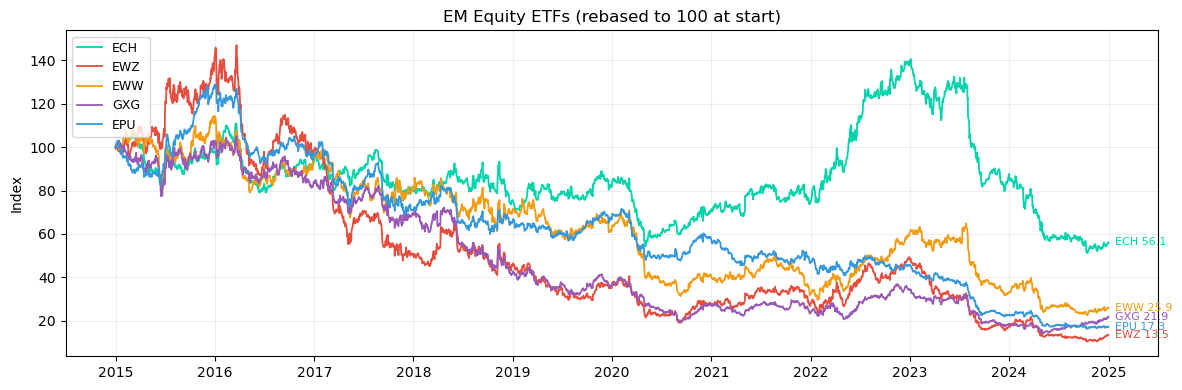

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
for i, col in enumerate(eq_prices.columns):
    s = eq_prices[col].dropna()
    rebased = s / s.iloc[0] * 100
    ax.plot(rebased.index, rebased, label=col, color=colors[i], lw=1.3)
    ax.annotate(f'{col} {rebased.iloc[-1]:.1f}',
                xy=(rebased.index[-1], rebased.iloc[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color=colors[i], va='center')
ax.set_title('EM Equity ETFs (rebased to 100 at start)')
ax.set_ylabel('Index')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## 6 · Pairwise Correlation Heatmap — Calm vs Stress periods

Calm: 2018-01-01 to 2019-12-31.  Stress: 2020-02-20 to 2020-04-30 (COVID).


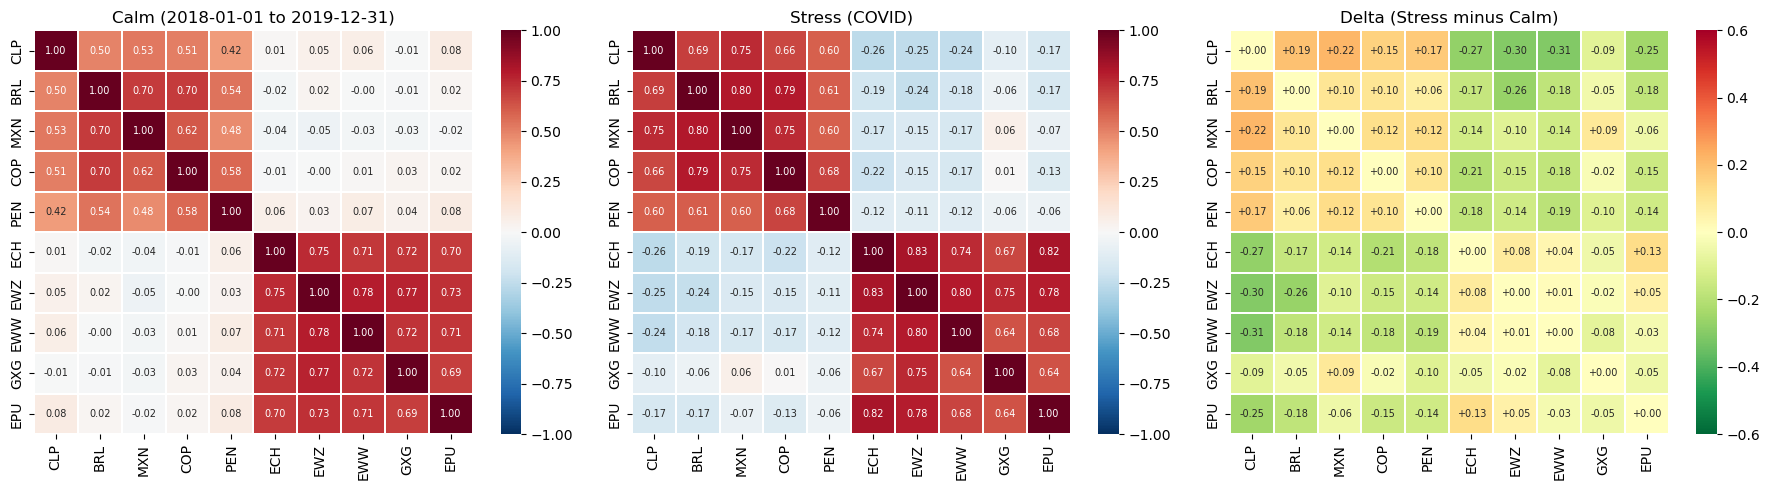

Avg off-diag corr  Calm:   0.294
Avg off-diag corr  Stress: 0.239


In [6]:
CALM_START,  CALM_END   = '2018-01-01', '2019-12-31'
STRESS_START, STRESS_END = '2020-02-20', '2020-04-30'

panel_ret = pd.concat([fx_ret, eq_ret], axis=1).dropna(how='all')
corr_calm   = panel_ret.loc[CALM_START:CALM_END].corr()
corr_stress = panel_ret.loc[STRESS_START:STRESS_END].corr()
corr_delta  = corr_stress - corr_calm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(vmin=-1, vmax=1, cmap='RdBu_r', annot=True, fmt='.2f',
          linewidths=0.3, annot_kws={'size': 7})
sns.heatmap(corr_calm,   ax=axes[0], **kw)
axes[0].set_title(f'Calm ({CALM_START} to {CALM_END})')
sns.heatmap(corr_stress, ax=axes[1], **kw)
axes[1].set_title('Stress (COVID)')
dkw = dict(vmin=-0.6, vmax=0.6, cmap='RdYlGn_r', annot=True, fmt='+.2f',
           linewidths=0.3, annot_kws={'size': 7})
sns.heatmap(corr_delta,  ax=axes[2], **dkw)
axes[2].set_title('Delta (Stress minus Calm)')
plt.tight_layout(); plt.show()

mask = ~np.eye(len(corr_calm), dtype=bool)
print(f'Avg off-diag corr  Calm:   {corr_calm.where(mask).stack().mean():.3f}')
print(f'Avg off-diag corr  Stress: {corr_stress.where(mask).stack().mean():.3f}')


## 7 · Manual Spot-Check

Pick any date and verify the stored price is consistent with log-returns.
In live mode: compare against Yahoo Finance / BCCh for that ticker and date.


In [7]:
CHECK_DATE   = '2020-03-20'
CHECK_SERIES = fx_prices.columns[0]   # first FX series

# find nearest trading day in index
idx_arr = fx_prices.index
loc = idx_arr.get_indexer([pd.Timestamp(CHECK_DATE)], method='nearest')[0]
audit_date = idx_arr[loc]
print(f'Check date (nearest trading day): {audit_date.date()}')

stored_price = float(fx_prices.iloc[loc][CHECK_SERIES])
print(f'Stored  {CHECK_SERIES} price: {stored_price:.4f}')

# consistency check: reconstruct from log-return
if loc > 0 and CHECK_SERIES in fx_ret.columns and audit_date in fx_ret.index:
    prev_price   = float(fx_prices.iloc[loc - 1][CHECK_SERIES])
    log_ret_t    = float(fx_ret.loc[audit_date, CHECK_SERIES])
    reconstructed = prev_price * np.exp(log_ret_t)
    diff = abs(stored_price - reconstructed)
    print(f'Prev price          : {prev_price:.4f}')
    print(f'Log return on date  : {log_ret_t:.6f}')
    print(f'Reconstructed price : {reconstructed:.4f}')
    print(f'Absolute difference : {diff:.6f}')
    status = 'OK' if diff < 0.01 else 'DISCREPANCY — investigate'
    print(f'Consistency check   : {status}')
else:
    print('Cannot reconstruct (first row or series not in returns index)')


Check date (nearest trading day): 2020-03-20
Stored  CLP price: 39.8638
Prev price          : 40.6295
Log return on date  : -0.018847
Reconstructed price : 39.8709
Absolute difference : 0.007171
Consistency check   : OK
